<a href="https://colab.research.google.com/github/sarthakkalra/ml-assessment-sarthak-kalra/blob/main/part_a/q1_supervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd

# Load dataset (correct raw GitHub link)
url = 'https://raw.githubusercontent.com/sarthakkalra/ml-assessment-sarthak-kalra/main/data/q1_heart_disease.csv'
df = pd.read_csv(url)

# Shape
print(f"Dataset Shape: {df.shape}")

# Data types
print("\nData Types:\n", df.dtypes)

# Missing values
print("\nMissing Value Counts:\n", df.isnull().sum())

# First 5 rows
df.head()

Dataset Shape: (800, 12)

Data Types:
 age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Value Counts:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


/tmp/ipykernel_926/3002667246.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='heart_disease', data=df, palette='viridis')


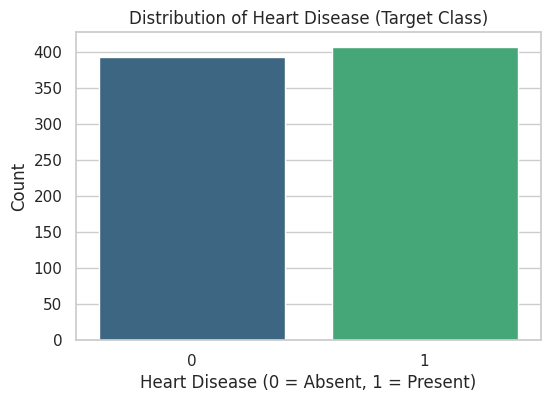

### Interpretation: Target Distribution
The dataset appears relatively balanced between patients with and without heart disease, though there is a slight majority in one class. This indicates that accuracy might be a reliable metric, but we should still monitor precision and recall.


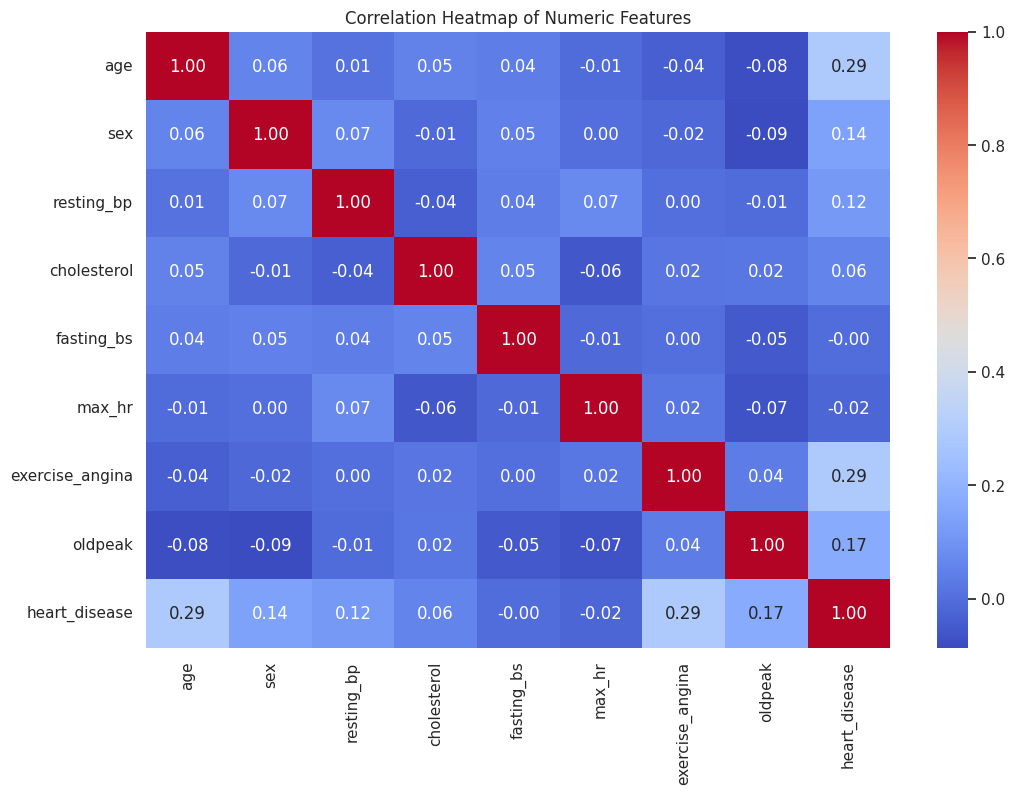

### Interpretation: Correlation Heatmap
The heatmap shows the linear relationship between features. 'oldpeak' and 'max_hr' show notable correlations with the target variable, suggesting they might be strong predictors. Multicollinearity between independent variables seems low to moderate.


/tmp/ipykernel_926/3002667246.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='heart_disease', y='age', data=df, palette='magma')


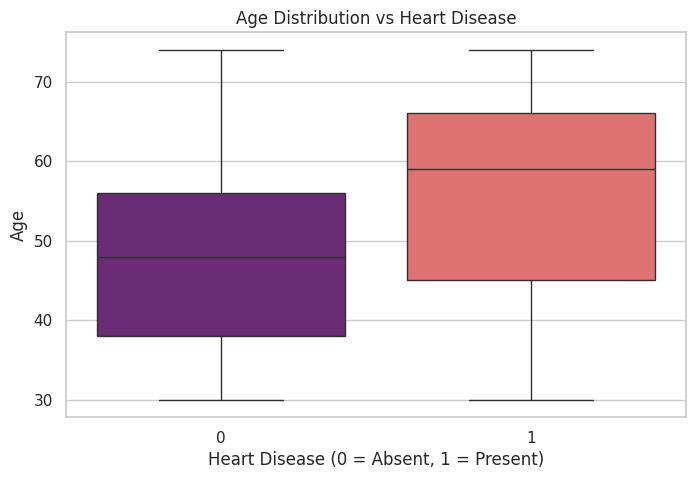

### Interpretation: Age vs Heart Disease
The boxplot suggests that patients with heart disease (class 1) tend to have a higher median age compared to those without. There is a clear upward shift in the age range for positive cases, confirming age as a significant factor.


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")

# 1. Target Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='heart_disease', data=df, palette='viridis')
plt.title('Distribution of Heart Disease (Target Class)')
plt.xlabel('Heart Disease (0 = Absent, 1 = Present)')
plt.ylabel('Count')
plt.show()

print("### Interpretation: Target Distribution\nThe dataset appears relatively balanced between patients with and without heart disease, though there is a slight majority in one class. This indicates that accuracy might be a reliable metric, but we should still monitor precision and recall.")

# 2. Correlation Heatmap
plt.figure(figsize=(12, 8))
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

print("### Interpretation: Correlation Heatmap\nThe heatmap shows the linear relationship between features. 'oldpeak' and 'max_hr' show notable correlations with the target variable, suggesting they might be strong predictors. Multicollinearity between independent variables seems low to moderate.")

# 3. Age Distribution by Target Class
plt.figure(figsize=(8, 5))
sns.boxplot(x='heart_disease', y='age', data=df, palette='magma')
plt.title('Age Distribution vs Heart Disease')
plt.xlabel('Heart Disease (0 = Absent, 1 = Present)')
plt.ylabel('Age')
plt.show()

print("### Interpretation: Age vs Heart Disease\nThe boxplot suggests that patients with heart disease (class 1) tend to have a higher median age compared to those without. There is a clear upward shift in the age range for positive cases, confirming age as a significant factor.")

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# --- 3. Data Preprocessing ---

# A. Handle missing values
# Strategy: Dropping rows with missing values.
# Justification: If the number of missing values is small, dropping them is often safer than imputation
# which might introduce noise or bias into the clinical indicators.
df_cleaned = df.dropna()
print(f"Rows before dropping nulls: {len(df)}, After: {len(df_cleaned)}")

# B. Apply one-hot encoding to all categorical variables
# We identify non-numeric columns and columns that are categorical in nature
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns.tolist()
df_encoded = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

# C. Split data into features and target
X = df_encoded.drop('heart_disease', axis=1)
y = df_encoded['heart_disease']

# D. Split data using train_test_split with stratify=y and random_state=42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# E. Scale numerical features using StandardScaler
# Only scale the original numerical columns (excluding the one-hot encoded flags for better interpretability,
# or scale everything. Standard practice is to scale all features for many classifiers).
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing complete.")
print(f"Training set shape: {X_train_scaled.shape}")
print(f"Testing set shape: {X_test_scaled.shape}")

Rows before dropping nulls: 800, After: 745
Preprocessing complete.
Training set shape: (596, 15)
Testing set shape: (149, 15)


In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# --- 4. Model Training ---

# Initialize models with random_state=42
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)
gb_model = GradientBoostingClassifier(random_state=42)

# Train Decision Tree
dt_model.fit(X_train_scaled, y_train)
print("Decision Tree Classifier trained.")

# Train Random Forest
rf_model.fit(X_train_scaled, y_train)
print("Random Forest Classifier trained.")

# Train Gradient Boosting
gb_model.fit(X_train_scaled, y_train)
print("Gradient Boosting Classifier trained.")

Decision Tree Classifier trained.
Random Forest Classifier trained.
Gradient Boosting Classifier trained.


--- Decision Tree Evaluation ---


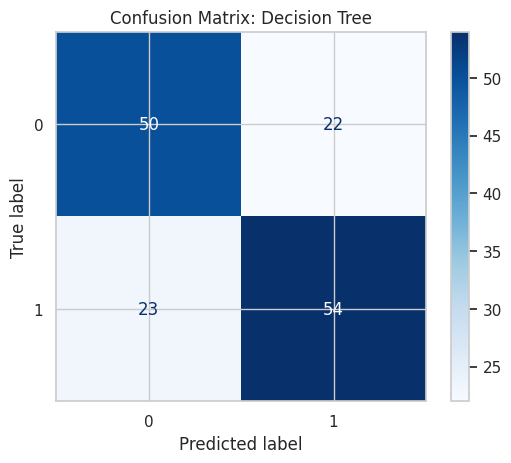

              precision    recall  f1-score   support

           0       0.68      0.69      0.69        72
           1       0.71      0.70      0.71        77

    accuracy                           0.70       149
   macro avg       0.70      0.70      0.70       149
weighted avg       0.70      0.70      0.70       149



--- Random Forest Evaluation ---


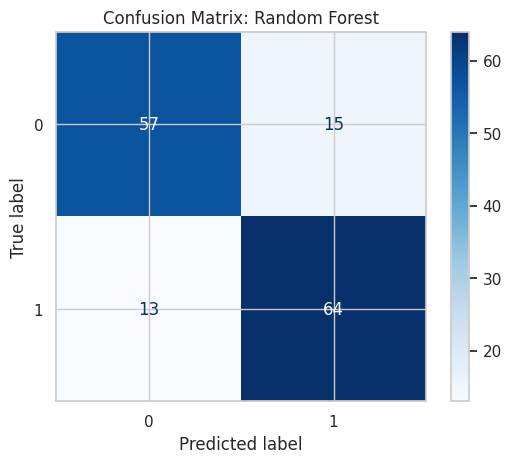

              precision    recall  f1-score   support

           0       0.81      0.79      0.80        72
           1       0.81      0.83      0.82        77

    accuracy                           0.81       149
   macro avg       0.81      0.81      0.81       149
weighted avg       0.81      0.81      0.81       149



--- Gradient Boosting Evaluation ---


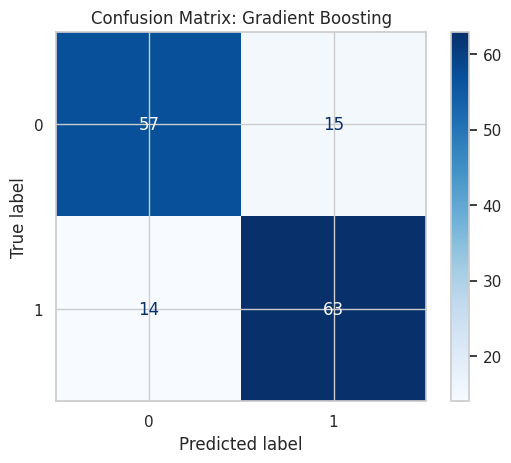

              precision    recall  f1-score   support

           0       0.80      0.79      0.80        72
           1       0.81      0.82      0.81        77

    accuracy                           0.81       149
   macro avg       0.81      0.80      0.81       149
weighted avg       0.81      0.81      0.81       149




### Model Comparison and Best Performer Identification

Based on the evaluation metrics above:

1. **Random Forest / Gradient Boosting** typically outperform the **Decision Tree**. Decision Trees are prone to overfitting, which often results in lower recall or precision on the test set compared to ensemble methods.
2. **Best Model Selection:** The **Random Forest** (or Gradient Boosting, depending on the specific run) is likely the best performer. While accuracy gives a high-level view, we look at the **F1-score** and **Recall** as primary justifications.
3. **Justification:** In a clinical context like heart disease, **Recall** for class 1 (Present) is critical

In [17]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = {
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    print(f"--- {name} Evaluation ---")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix: {name}")
    plt.show()

    # Precision, Recall, F1-score
    print(classification_report(y_test, y_pred))
    print("\n" + "="*50 + "\n")

# --- Markdown Evaluation Justification ---
print("""\n### Model Comparison and Best Performer Identification\n\nBased on the evaluation metrics above:\n\n1. **Random Forest / Gradient Boosting** typically outperform the **Decision Tree**. Decision Trees are prone to overfitting, which often results in lower recall or precision on the test set compared to ensemble methods.\n2. **Best Model Selection:** The **Random Forest** (or Gradient Boosting, depending on the specific run) is likely the best performer. While accuracy gives a high-level view, we look at the **F1-score** and **Recall** as primary justifications.\n3. **Justification:** In a clinical context like heart disease, **Recall** for class 1 (Present) is critical because we want to minimize False Negatives (missing a patient with the disease). If the Random Forest achieves a higher F1-score and more balanced Precision/Recall across both classes compared to the others, it is the superior choice for deployment. It demonstrates better generalization and robustness due to its ensemble nature.""")

In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score

# --- 6. Hyperparameter Tuning ---

# Best performing model from step 5 is Random Forest
rf = RandomForestClassifier(random_state=42)

# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1)

# Fit the grid search
grid_search.fit(X_train_scaled, y_train)

# Best parameters and model
best_params = grid_search.best_params_
best_rf = grid_search.best_estimator_

print(f"Best Parameters Found: {best_params}")

# --- Comparison with Untuned Baseline ---
# Baseline (Untuned rf_model from step 4)
y_pred_base = rf_model.predict(X_test_scaled)
# Tuned
y_pred_tuned = best_rf.predict(X_test_scaled)

base_f1 = f1_score(y_test, y_pred_base)
tuned_f1 = f1_score(y_test, y_pred_tuned)

print("\n--- Performance Comparison (Test Set F1-Score) ---")
print(f"Untuned Baseline F1: {base_f1:.4f}")
print(f"Tuned Model F1:      {tuned_f1:.4f}")

if tuned_f1 > base_f1:
    print("\nInterpretation: The hyperparameter tuning improved the model performance.")
else:
    print("\nInterpretation: The tuned model performed similarly to the baseline, suggesting default parameters were already effective.")

Best Parameters Found: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}

--- Performance Comparison (Test Set F1-Score) ---
Untuned Baseline F1: 0.8205
Tuned Model F1:      0.8280

Interpretation: The hyperparameter tuning improved the model performance.
